# Keyword Analysis — Priorità (P1/P2/P3/P4)

Obiettivo: trovare i termini più discriminanti per ogni classe di priorità usando TF-IDF + chi-quadro.

**Sezioni:**
1. Import e caricamento dati
2. TF-IDF sul corpus completo
3. Chi-quadro one-vs-rest per P1/P2/P3/P4
4. Focus P1 vs P2 (confronto diretto, escludendo P3/P4)
5. Overlap analysis — parole confondenti P1/P2
6. Grafici (bar, wordcloud, heatmap)
7. Salvataggio CSV


---
## STEP 1 — Import e caricamento dati

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import chi2
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# notebooks/analysis/ → .parent → notebooks/ → .parent → TicketClassifier/
BASE_DIR = Path(os.path.abspath('')).parent.parent
CSV_PATH = BASE_DIR / 'data' / 'dataset_clean.csv'
OUT_PATH = BASE_DIR / 'data' / 'keyword_analysis_priority.csv'

df = pd.read_csv(CSV_PATH)
print(f'Righe caricate: {len(df):,}')
print(f'Colonne: {df.columns.tolist()}')
print()
print('Distribuzione priorità_finale:')
print(df['priorita_finale'].value_counts().sort_index())

Righe caricate: 61,156
Colonne: ['url_ticket', 'case_number', 'testo_input', 'priorita_finale', 'priorita_iniziale_cliente', 'area', 'articolo', 'modulo_sw', 'data_creazione', 'kw_s381_codice', 'kw_s381_rapportino', 'kw_s381_timbrate', 'kw_s381_calendario_presenze', 'kw_ter_unodomo', 'kw_ter_distretto', 'kw_san_terapia', 'kw_san_pai', 'kw_san_css', 'kw_san_diario', 'kw_san_contenzioni', 'kw_san_farmaco', 'kw_pas_iva', 'kw_pas_cespiti', 'kw_pas_prima_nota', 'kw_pas_ammortamento', 'kw_pas_analitica', 'kw_pas_reverse', 'kw_pas_fornitore', 'kw_att_retta', 'kw_att_pagopa', 'kw_att_sdd', 'kw_att_portale_utenti', 'kw_att_fattura_elettronica', 'kw_sis_installazione_programma', 'kw_s381_commessa', 'kw_s381_lotto', 'kw_s381_reinvio', 'kw_s381_noriller', 'kw_s381_cescatti', 'kw_ter_sad', 'kw_ter_udo', 'kw_ter_giada', 'kw_sis_sipcar', 'kw_sis_vpn', 'kw_sis_rdp', 'kw_sis_server_cloud', 'kw_pas_bilancio', 'kw_pas_registrazione', 'kw_att_fatturazione', 'kw_att_sdi']

Distribuzione priorità_finale:
pr

In [3]:
# Pulizia: teniamo solo ticket con priorità valorizzata e testo non vuoto
df_validi = df.dropna(subset=['priorita_finale', 'testo_input']).copy()
df_validi = df_validi[df_validi['priorita_finale'].isin(['P1', 'P2', 'P3', 'P4'])].copy()
df_validi['testo_lower'] = df_validi['testo_input'].str.lower()

print(f'Ticket usabili: {len(df_validi):,}')
print()
print('Distribuzione classi:')
print(df_validi['priorita_finale'].value_counts().sort_index())

Ticket usabili: 61,156

Distribuzione classi:
priorita_finale
P1     8381
P2    17737
P3    33496
P4     1542
Name: count, dtype: int64


---
## STEP 2 — TF-IDF sul corpus completo

Unigrammi + bigrammi, almeno 10 doc, stopwords italiane + custom di dominio.
`sublinear_tf=True` riduce il peso dei termini molto frequenti (log scaling).

In [4]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Stopwords italiane base (lista comune)
STOPWORDS_IT = {
    'a','ad','ai','al','alla','allo','alle','agli','anche','ancora','anzi','appena',
    'avere','avuto','che','chi','ci','come','con','contro','cosa','cui','da','dagli',
    'dai','dal','dalla','dalle','dallo','degli','dei','del','della','delle','dello',
    'di','dopo','dove','e','ed','è','era','erano','essere','fa','fin','fino','fra',
    'già','gli','ha','hanno','ho','i','il','in','infatti','invece','io','la','le',
    'li','lo','lui','ma','mi','mia','mie','miei','mio','molto','nei','nel','nella',
    'nelle','nello','no','non','o','ogni','ora','per','perché','però','più','poi',
    'prima','proprio','quando','qui','se','si','sia','solo','sono','su','sua','sue',
    'sugli','sui','sul','sulla','sulle','sullo','suoi','suo','te','ti','tra','tu',
    'tua','tue','tuoi','tuo','tutti','tutto','un','una','uno','vi','via','volta',
    'voi','con','nelle','degli','negli'
}

# Stopwords di dominio (formule di cortesia, parole neutre)
STOPWORDS_DOMINIO = {
    'buongiorno', 'salve', 'cordiali', 'saluti', 'gentile', 'seguito',
    'presente', 'ticket', 'grazie', 'buona', 'giornata', 'distinti',
    'prego', 'subito', 'oggi', 'giorno', 'caso', 'parte', 'modo',
    'fare', 'fatto', 'vedere', 'volte', 'volta', 'tipo', 'numero',
    'nuovo', 'nuova', 'nuovi', 'nuovo', 'riguarda', 'segnala', 'segnalo',
    'segnalare', 'allego', 'allegato', 'allegati', 'indica', 'indicato',
    'specificato', 'riportato', 'evidenziato', 'comunicare', 'comunicato',
    'verificare', 'verificato', 'riscontrare', 'riscontrato', 'notare',
    'notato', 'aggiornare', 'aggiornato', 'aprire', 'aperto', 'chiudere',
    'chiuso', 'inserire', 'inserito', 'eliminare', 'eliminato', 'aprire',
    'chiedere', 'chiedo', 'chiede', 'chiedevamo', 'richiesta', 'richiesto',
    'puo', 'può', 'gia', 'già', 'poi', 'sia', 'anche', 'come', 'quando',
    'dove', 'perche', 'perché', 'cosi', 'così', 'quindi', 'però', 'oppure',
    'essere', 'avere', 'fare', 'stare', 'andare', 'venire', 'dare', 'dire',
}

ALL_STOPWORDS = list(STOPWORDS_IT | STOPWORDS_DOMINIO)

vec = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=10,
    max_features=15_000,
    sublinear_tf=True,
    stop_words=ALL_STOPWORDS,
)

X_tfidf = vec.fit_transform(df_validi['testo_lower'])
termini = vec.get_feature_names_out()

print(f'Matrice TF-IDF: {X_tfidf.shape}  ({X_tfidf.shape[1]} termini)')

Matrice TF-IDF: (61156, 15000)  (15000 termini)


---
## STEP 3 — Chi-quadro one-vs-rest per ogni priorità

Per ogni classe: rank, termine, chi2 score, precision, recall, n_occorrenze.

In [5]:
CLASSI_TARGET = ['P1', 'P2', 'P3', 'P4']
TOP_N = 30

righe = []

for classe in CLASSI_TARGET:
    y_bin = (df_validi['priorita_finale'] == classe).astype(int).values
    n_pos = y_bin.sum()

    chi_scores, pvals = chi2(X_tfidf, y_bin)
    top_idx = chi_scores.argsort()[::-1][:TOP_N]

    for rank, idx in enumerate(top_idx, start=1):
        termine = termini[idx]
        score   = chi_scores[idx]
        pval    = pvals[idx]

        mask_termine = np.asarray(X_tfidf[:, idx].todense()).flatten() > 0
        n_con_termine = mask_termine.sum()
        n_classe_con_termine = (mask_termine & (y_bin == 1)).sum()
        precision = n_classe_con_termine / n_con_termine if n_con_termine > 0 else 0
        recall    = n_classe_con_termine / n_pos if n_pos > 0 else 0

        righe.append({
            'classe':       classe,
            'rank':         rank,
            'termine':      termine,
            'chi2':         round(score, 1),
            'pval':         round(pval, 6),
            'precision':    round(precision, 3),
            'recall':       round(recall, 3),
            'n_occorrenze': int(n_con_termine),
            'n_classe':     int(n_pos),
        })

    print(f'{classe}  ({n_pos:,} ticket) — analisi completata')

df_kw = pd.DataFrame(righe)
print(f'\nTabella risultati: {len(df_kw)} righe')

P1  (8,381 ticket) — analisi completata
P2  (17,737 ticket) — analisi completata
P3  (33,496 ticket) — analisi completata
P4  (1,542 ticket) — analisi completata

Tabella risultati: 120 righe


In [6]:
pd.set_option('display.max_rows', 50)
pd.set_option('display.max_colwidth', 40)
pd.set_option('display.float_format', '{:.3f}'.format)

for classe in CLASSI_TARGET:
    subset = df_kw[df_kw['classe'] == classe].head(20)
    print(f'\n{"="*70}')
    print(f'  {classe}  —  {subset["n_classe"].iloc[0]:,} ticket')
    print(f'{"="*70}')
    print(subset[['rank', 'termine', 'chi2', 'precision', 'recall', 'n_occorrenze']].to_string(index=False))


  P1  —  8,381 ticket
 rank            termine    chi2  precision  recall  n_occorrenze
    1            urgente 331.800      0.437   0.136          2598
    2            urgenza 193.800      0.436   0.084          1622
    3           bloccato 116.400      0.415   0.028           568
    4       urgentemente 104.100      0.485   0.031           532
    5       urgentissimo  93.000      0.616   0.012           159
    6 riusciamo accedere  92.800      0.590   0.013           183
    7           funziona  86.600      0.287   0.042          1230
    8           stipendi  77.300      0.306   0.064          1741
    9           bloccati  73.900      0.595   0.012           173
   10           accedere  61.400      0.260   0.056          1796
   11 intervento urgente  60.100      0.524   0.012           185
   12              katia  57.500      0.422   0.016           308
   13        funzionante  56.900      0.398   0.014           299
   14              paghe  55.300      0.284   0.050  

---
## STEP 4 — Focus P1 vs P2

Analisi separata: confronto diretto P1 contro P2, escludendo P3 e P4.
Questo evidenzia cosa differenzia semanticamente le due classi più simili.

In [7]:
# Sottoinsieme P1+P2 soltanto
df_p1p2 = df_validi[df_validi['priorita_finale'].isin(['P1', 'P2'])].copy()
print(f'Ticket P1+P2: {len(df_p1p2):,}')
print(df_p1p2['priorita_finale'].value_counts())

# Nuovo vettorizzatore sul solo sottoinsieme P1/P2
vec_p1p2 = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=5,
    max_features=15_000,
    sublinear_tf=True,
    stop_words=ALL_STOPWORDS,
)
X_p1p2 = vec_p1p2.fit_transform(df_p1p2['testo_lower'])
termini_p1p2 = vec_p1p2.get_feature_names_out()
print(f'\nMatrice TF-IDF P1/P2: {X_p1p2.shape}')

Ticket P1+P2: 26,118
priorita_finale
P2    17737
P1     8381
Name: count, dtype: int64

Matrice TF-IDF P1/P2: (26118, 15000)


In [8]:
TOP_N_FOCUS = 30

righe_p1p2 = []

for classe in ['P1', 'P2']:
    y_bin = (df_p1p2['priorita_finale'] == classe).astype(int).values
    n_pos = y_bin.sum()

    chi_scores, pvals = chi2(X_p1p2, y_bin)
    top_idx = chi_scores.argsort()[::-1][:TOP_N_FOCUS]

    for rank, idx in enumerate(top_idx, start=1):
        termine = termini_p1p2[idx]
        score   = chi_scores[idx]
        pval    = pvals[idx]

        mask_termine = np.asarray(X_p1p2[:, idx].todense()).flatten() > 0
        n_con_termine = mask_termine.sum()
        n_classe_con_termine = (mask_termine & (y_bin == 1)).sum()
        precision = n_classe_con_termine / n_con_termine if n_con_termine > 0 else 0
        recall    = n_classe_con_termine / n_pos if n_pos > 0 else 0

        righe_p1p2.append({
            'classe':       classe,
            'rank':         rank,
            'termine':      termine,
            'chi2':         round(score, 1),
            'pval':         round(pval, 6),
            'precision':    round(precision, 3),
            'recall':       round(recall, 3),
            'n_occorrenze': int(n_con_termine),
            'n_classe':     int(n_pos),
        })

    print(f'{classe}  ({n_pos:,} ticket) — analisi P1vsP2 completata')

df_kw_p1p2 = pd.DataFrame(righe_p1p2)

# Stampa risultati
for classe in ['P1', 'P2']:
    subset = df_kw_p1p2[df_kw_p1p2['classe'] == classe].head(20)
    print(f'\n{"="*70}')
    altre = 'P2' if classe == 'P1' else 'P1'
    print(f'  {classe} vs {altre}  —  {subset["n_classe"].iloc[0]:,} ticket')
    print(f'{"="*70}')
    print(subset[['rank', 'termine', 'chi2', 'precision', 'recall', 'n_occorrenze']].to_string(index=False))

P1  (8,381 ticket) — analisi P1vsP2 completata
P2  (17,737 ticket) — analisi P1vsP2 completata

  P1 vs P2  —  8,381 ticket
 rank            termine   chi2  precision  recall  n_occorrenze
    1            urgente 79.100      0.565   0.136          2009
    2            fattura 44.200      0.144   0.036          2084
    3            urgenza 41.100      0.547   0.084          1292
    4           presenze 34.900      0.493   0.080          1360
    5           funziona 34.800      0.510   0.042           692
    6           bloccato 34.300      0.581   0.028           406
    7 riusciamo accedere 33.200      0.783   0.013           138
    8           accedere 32.600      0.512   0.056           913
    9              katia 30.200      0.739   0.016           176
   10                iva 27.900      0.124   0.012           832
   11           stipendi 27.500      0.504   0.064          1057
   12       urgentissimo 26.900      0.721   0.012           136
   13            fatture 26.800

---
## STEP 5 — Overlap Analysis P1/P2

Parole che appaiono frequentemente in **entrambe** P1 e P2: sono le parole "confondenti"
che spiegano perché il modello fatica a discriminare le due classi.

Metrica: per ogni termine calcoliamo la frequenza relativa in P1 e in P2 (% di ticket della classe che lo contengono).
Le parole confondenti hanno frequenza alta in entrambe (entrambe > soglia).

In [9]:
# Calcoliamo per ogni termine la % di ticket P1 e P2 che lo contengono
mask_p1 = (df_validi['priorita_finale'] == 'P1').values
mask_p2 = (df_validi['priorita_finale'] == 'P2').values
n_p1 = mask_p1.sum()
n_p2 = mask_p2.sum()

overlap_rows = []
# Usiamo X_tfidf sul corpus totale, in modo da avere stesso vocabolario
for idx in range(X_tfidf.shape[1]):
    col = np.asarray(X_tfidf[:, idx].todense()).flatten() > 0
    freq_p1 = col[mask_p1].sum() / n_p1
    freq_p2 = col[mask_p2].sum() / n_p2
    # Overlap score: minimo delle due frequenze (se entrambe alte = alta confusione)
    overlap = min(freq_p1, freq_p2)
    if overlap > 0.01:  # almeno 1% in entrambe
        overlap_rows.append({
            'termine':   termini[idx],
            'freq_P1':   round(freq_p1, 4),
            'freq_P2':   round(freq_p2, 4),
            'overlap':   round(overlap, 4),
            'n_tot':     int(col.sum()),
        })

df_overlap = pd.DataFrame(overlap_rows).sort_values('overlap', ascending=False).reset_index(drop=True)

# Top 40 parole più confondenti
TOP_OVERLAP = 40
df_overlap_top = df_overlap.head(TOP_OVERLAP)

print(f'Termini con overlap > 1% in P1 e P2: {len(df_overlap):,}')
print()
print('Top 40 parole confondenti:')
print(df_overlap_top[['termine', 'freq_P1', 'freq_P2', 'overlap', 'n_tot']].to_string(index=False))

Termini con overlap > 1% in P1 e P2: 414

Top 40 parole confondenti:
      termine  freq_P1  freq_P2  overlap  n_tot
       errore    0.238    0.210    0.210  11099
      abbiamo    0.148    0.140    0.140   7445
     problema    0.132    0.131    0.131   6291
    programma    0.145    0.117    0.117   6311
         2025    0.110    0.120    0.110   6539
    riscontro    0.109    0.114    0.109   5853
       quanto    0.111    0.106    0.106   5709
         dell    0.091    0.114    0.091   6458
       attesa    0.083    0.097    0.083   5080
       questo    0.082    0.086    0.082   5273
         dati    0.080    0.089    0.080   5010
    possibile    0.080    0.085    0.080   5743
       riesco    0.078    0.077    0.077   3976
       potete    0.073    0.079    0.073   4329
          all    0.073    0.078    0.073   4698
         file    0.073    0.072    0.072   3667
aggiornamento    0.101    0.072    0.072   4063
         2024    0.071    0.083    0.071   4178
   dipendente    0.

---
## STEP 6 — Grafici

### 6a — Top 20 keywords per classe (bar chart, chi2 score)
### 6b — Wordcloud per classe
### 6c — Heatmap overlap P1/P2

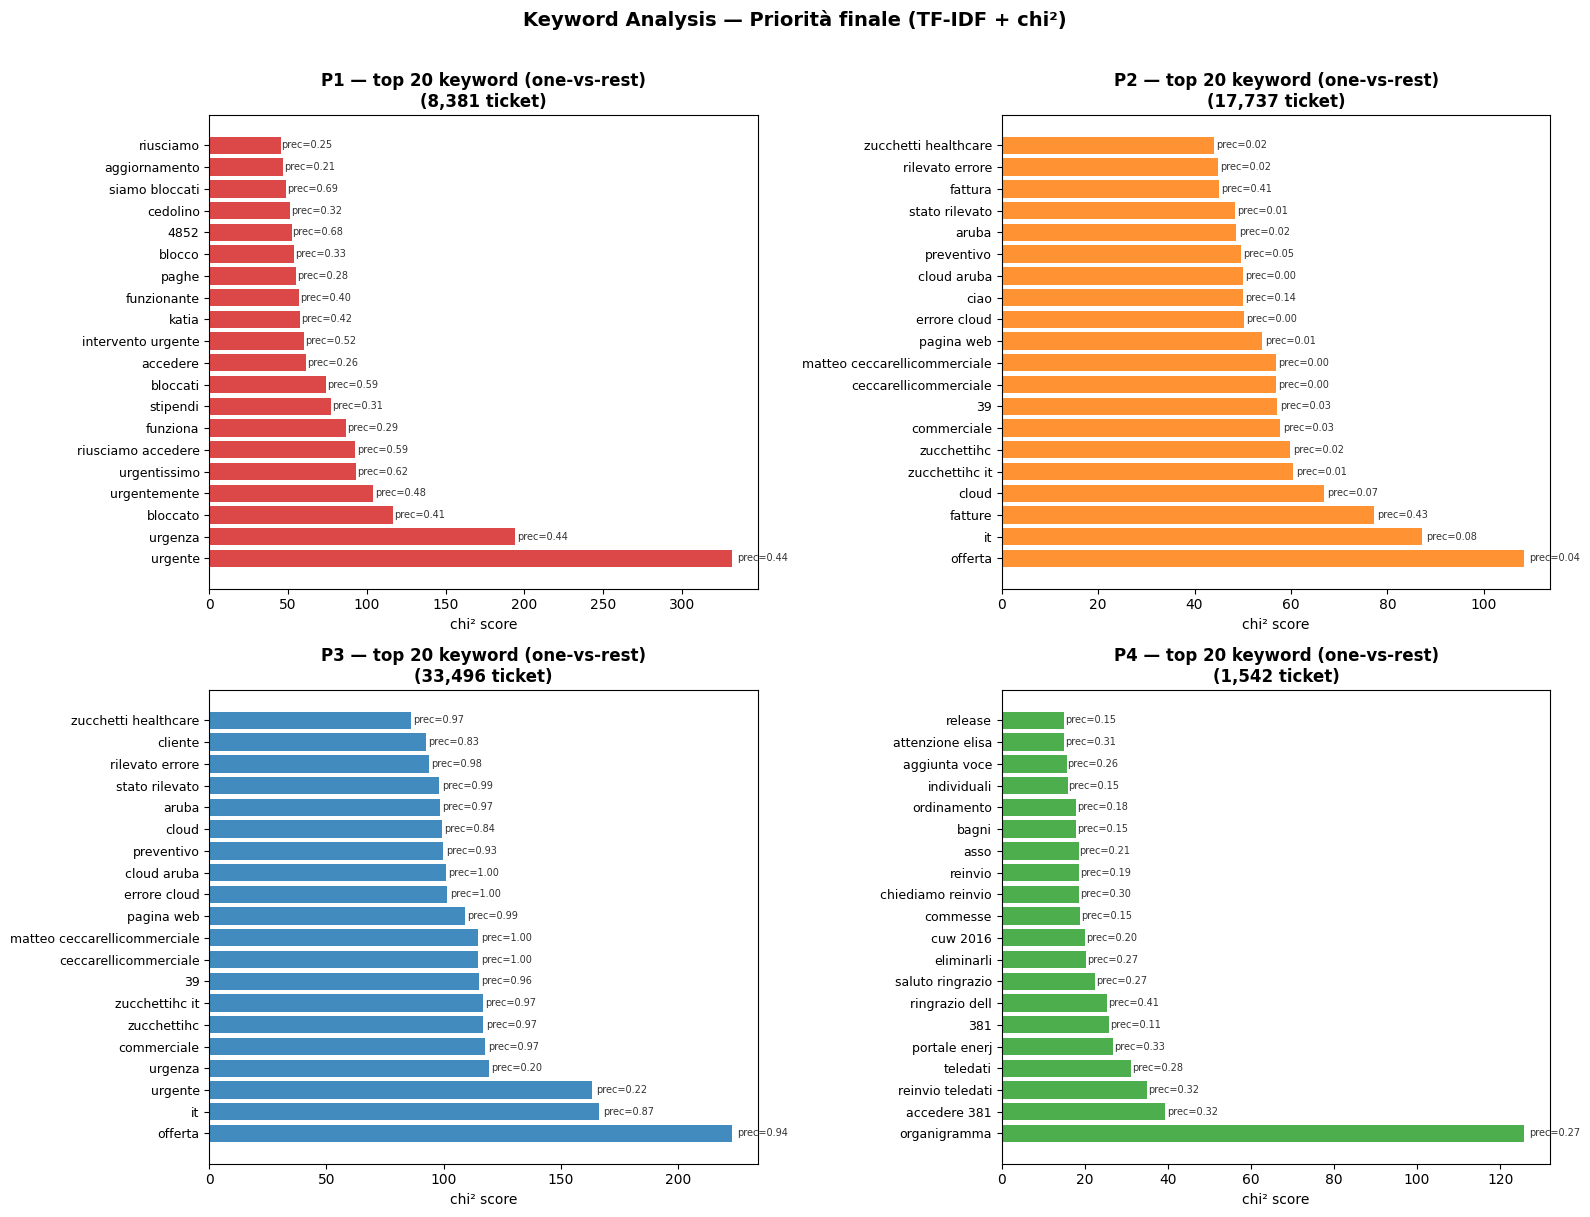

Grafico salvato: data/kw_priority_top20.png


In [10]:
### 6a — Bar chart: top 20 keywords per classe (chi2 score one-vs-rest)

COLORI = {'P1': '#d62728', 'P2': '#ff7f0e', 'P3': '#1f77b4', 'P4': '#2ca02c'}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, classe in enumerate(CLASSI_TARGET):
    ax = axes[i]
    subset = df_kw[df_kw['classe'] == classe].head(20).sort_values('chi2')
    
    bars = ax.barh(subset['termine'], subset['chi2'], color=COLORI[classe], alpha=0.85)
    
    # Annotazione precision su ogni barra
    for bar, (_, row) in zip(bars, subset.iterrows()):
        ax.text(
            bar.get_width() * 1.01,
            bar.get_y() + bar.get_height() / 2,
            f"prec={row['precision']:.2f}",
            va='center', fontsize=7, color='#333'
        )
    
    ax.set_title(f'{classe} — top 20 keyword (one-vs-rest)\n({subset["n_classe"].iloc[0]:,} ticket)',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('chi² score')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.tick_params(axis='y', labelsize=9)
    ax.invert_yaxis()

plt.suptitle('Keyword Analysis — Priorità finale (TF-IDF + chi²)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(BASE_DIR / 'data' / 'kw_priority_top20.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafico salvato: data/kw_priority_top20.png')

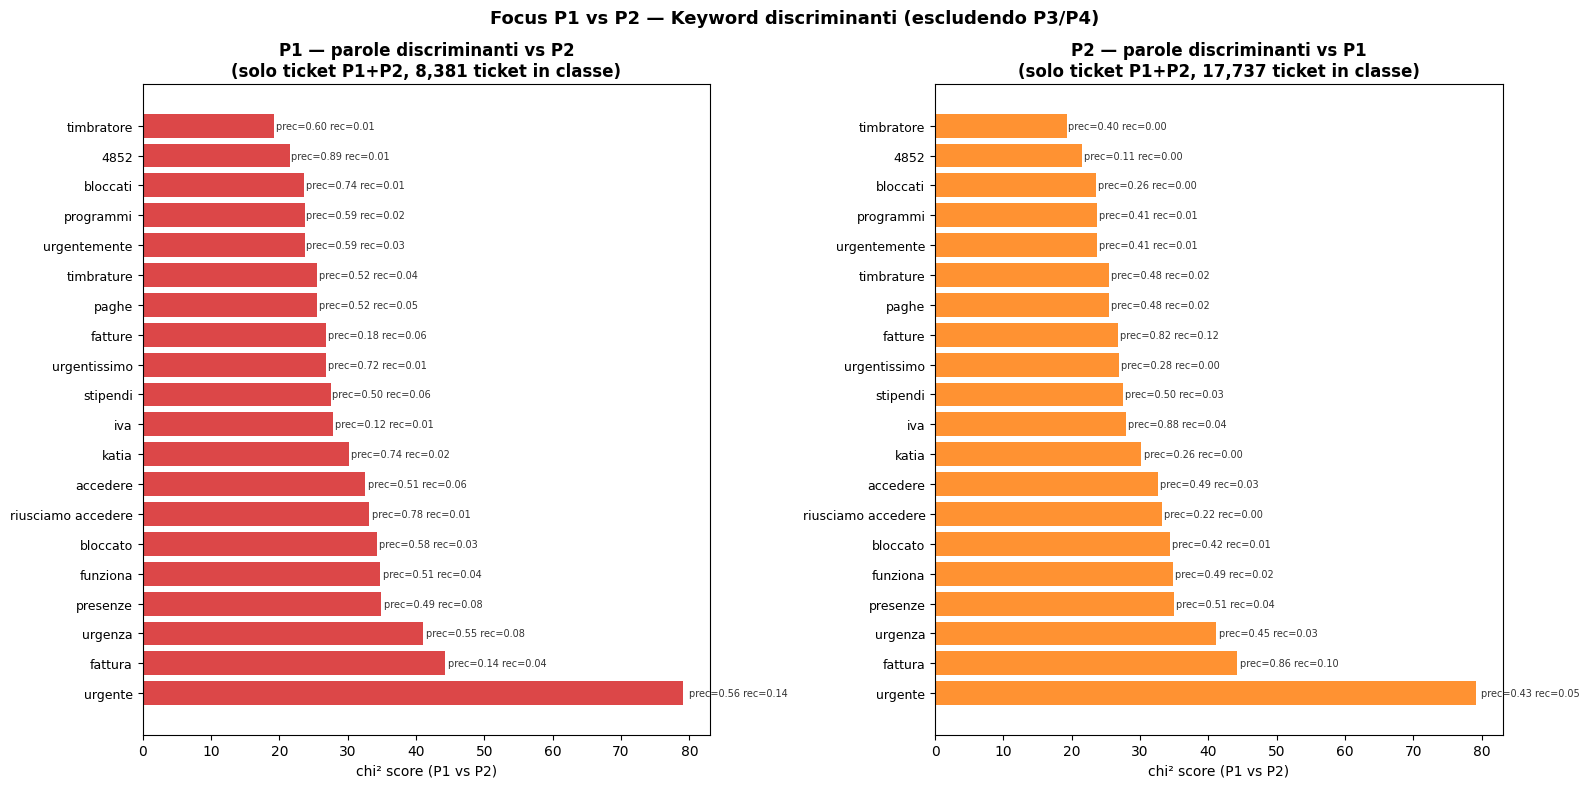

Grafico salvato: data/kw_p1_vs_p2_focus.png


In [ ]:
### 6b — Bar chart P1 vs P2: confronto diretto (analisi focus)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for i, classe in enumerate(['P1', 'P2']):
    ax = axes[i]
    subset = df_kw_p1p2[df_kw_p1p2['classe'] == classe].head(20).sort_values('chi2')
    
    bars = ax.barh(subset['termine'], subset['chi2'], color=COLORI[classe], alpha=0.85)
    
    for bar, (_, row) in zip(bars, subset.iterrows()):
        ax.text(
            bar.get_width() * 1.01,
            bar.get_y() + bar.get_height() / 2,
            f"prec={row['precision']:.2f} rec={row['recall']:.2f}",
            va='center', fontsize=7, color='#333'
        )
    
    ax.set_title(f'{classe} — parole discriminanti vs {"P2" if classe=="P1" else "P1"}\n'
                 f'(solo ticket P1+P2, {subset["n_classe"].iloc[0]:,} ticket in classe)',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('chi² score (P1 vs P2)')
    ax.tick_params(axis='y', labelsize=9)
    ax.invert_yaxis()

plt.suptitle('Focus P1 vs P2 — Keyword discriminanti (escludendo P3/P4)', fontsize=13, fontweight='bold')
plt.tight_layout()
#plt.savefig(BASE_DIR / 'data' / 'kw_p1_vs_p2_focus.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafico salvato: data/kw_p1_vs_p2_focus.png')

In [12]:
### 6c — Wordcloud per ogni classe (richiede wordcloud: pip install wordcloud)

try:
    from wordcloud import WordCloud

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.flatten()

    for i, classe in enumerate(CLASSI_TARGET):
        ax = axes[i]
        subset = df_kw[df_kw['classe'] == classe].head(30)
        # Dizionario termine → chi2 score come peso
        freq_dict = dict(zip(subset['termine'], subset['chi2']))

        wc = WordCloud(
            width=700, height=400,
            background_color='white',
            colormap='Reds' if classe == 'P1' else ('Oranges' if classe == 'P2' else ('Blues' if classe == 'P3' else 'Greens')),
            max_words=30,
            prefer_horizontal=0.8,
        ).generate_from_frequencies(freq_dict)

        ax.imshow(wc, interpolation='bilinear')
        ax.set_title(f'{classe} — wordcloud (peso = chi² score)', fontsize=12, fontweight='bold')
        ax.axis('off')

    plt.suptitle('Wordcloud per priorità — keyword discriminanti', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(BASE_DIR / 'data' / 'kw_priority_wordcloud.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Wordcloud salvato: data/kw_priority_wordcloud.png')

except ImportError:
    print('wordcloud non installato. Installa con: pip install wordcloud')
    print('Saltando wordcloud, continua con gli altri grafici.')

wordcloud non installato. Installa con: pip install wordcloud
Saltando wordcloud, continua con gli altri grafici.


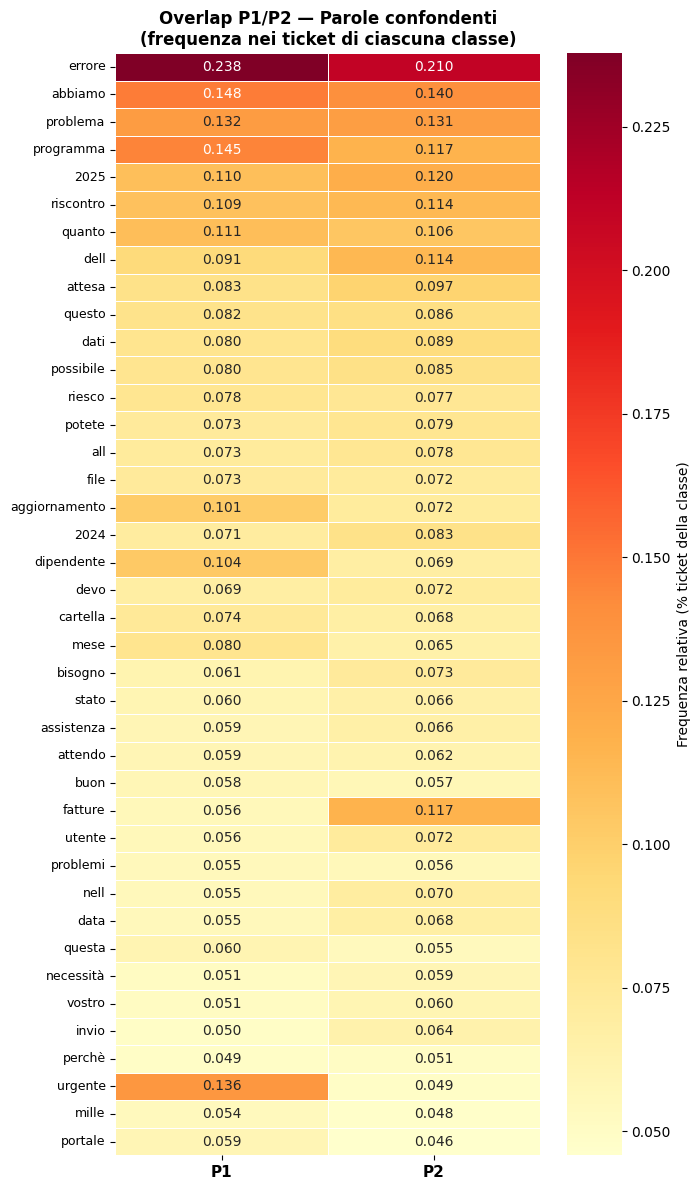

Heatmap salvata: data/kw_p1p2_overlap_heatmap.png


In [13]:
### 6d — Heatmap overlap P1/P2: top 40 parole confondenti

fig, ax = plt.subplots(figsize=(7, 12))

# Costruiamo matrice 40×2
hm_data = df_overlap_top.set_index('termine')[['freq_P1', 'freq_P2']]

sns.heatmap(
    hm_data,
    annot=True,
    fmt='.3f',
    cmap='YlOrRd',
    linewidths=0.4,
    ax=ax,
    cbar_kws={'label': 'Frequenza relativa (% ticket della classe)'},
)

ax.set_title(
    'Overlap P1/P2 — Parole confondenti\n'
    '(frequenza nei ticket di ciascuna classe)',
    fontsize=12, fontweight='bold'
)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=9)
ax.set_xticklabels(['P1', 'P2'], fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(BASE_DIR / 'data' / 'kw_p1p2_overlap_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Heatmap salvata: data/kw_p1p2_overlap_heatmap.png')